# Bloque III — Clasificación, matriz de confusión y ROC

**Duración estimada:** 3 horas  
**Dataset:** `../data/clientes_abandono_mayo_2026.csv`

## Objetivo de aprendizaje

El alumnado aprenderá a entrenar modelos de clasificación, interpretar sus métricas y ajustar decisiones en función del coste de falsos positivos y falsos negativos.

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:25 | Problemas de clasificación |
| 0:25–0:55 | Preparación de datos y balanceo |
| 0:55–1:25 | Regresión logística y árboles |
| 1:25–1:35 | Pausa |
| 1:35–2:10 | Accuracy, precision, recall y F1 |
| 2:10–2:35 | Matriz de confusión y ROC |
| 2:35–3:00 | Caso práctico |

In [1]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score,
    classification_report
)

## 1. Carga del dataset

El objetivo será predecir si un cliente abandonará (`abandono = 1`) o no (`abandono = 0`).

In [3]:
# Cargar el dataset
import os
# Ruta absoluta al archivo de datos
data_path = r'C:\Users\juang\OneDrive\Documentos\GitHub\Big_Data_2026\data\clientes_abandono_mayo_2026.csv'
print(f'Cargando datos desde: {data_path}')
df = pd.read_csv(data_path)
df.head()

Cargando datos desde: C:\Users\juang\OneDrive\Documentos\GitHub\Big_Data_2026\data\clientes_abandono_mayo_2026.csv


,edad,ingresos,compras_12m,visitas_web,reclamaciones,antiguedad_meses,ticket_medio,segmento,abandono
0,26,"37,808.670",10,18,0,62,87.270,Premium,0
1,32,"43,943.330",8,22,3,36,101.210,Premium,0
2,30,"49,516.390",16,26,1,75,12.500,Premium,0
3,39,"24,452.240",5,20,1,18,96.390,Estándar,0
4,33,"18,465.210",4,16,0,16,98.000,Estándar,0


## 2. Distribución de clases

En clasificación es fundamental revisar si las clases están balanceadas. Un dataset desequilibrado puede hacer que `accuracy` sea engañosa.

In [4]:
conteo = df["abandono"].value_counts()
proporcion = df["abandono"].value_counts(normalize=True)

display(conteo)
display(proporcion)

abandono
0    645
1     55
Name: count, dtype: int64

abandono
0   0.921
1   0.079
Name: proportion, dtype: float64

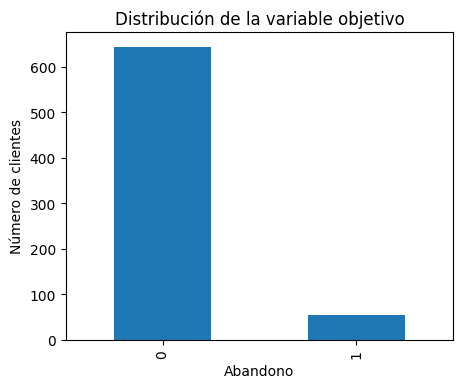

In [5]:
plt.figure(figsize=(5, 4))
conteo.plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Abandono")
plt.ylabel("Número de clientes")
plt.show()

## 3. Preparación de X e y

Separamos variables predictoras y variable objetivo. Usamos estratificación para conservar la proporción de clases en train y test.

In [6]:
target = "abandono"
features_num = ["edad", "ingresos", "compras_12m", "visitas_web", "reclamaciones", "antiguedad_meses", "ticket_medio"]
features_cat = ["segmento"]

X = df[features_num + features_cat]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

abandono
0   0.921
1   0.079
Name: proportion, dtype: float64
abandono
0   0.921
1   0.079
Name: proportion, dtype: float64


## 4. Preprocesamiento común

In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ]
)

## 5. Función de evaluación de clasificación

Calculamos métricas principales:

- Accuracy.
- Precision.
- Recall.
- F1.
- ROC AUC.

In [8]:
def evaluar_clasificador(nombre, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
    else:
        proba = None
        auc = np.nan

    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": auc
    }, pred, proba

## 6. Regresión logística

Modelo interpretable y muy usado como baseline en clasificación binaria.

In [9]:
logit = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

res_logit, pred_logit, proba_logit = evaluar_clasificador(
    "Logistic Regression", logit, X_train, X_test, y_train, y_test
)

res_logit

{'modelo': 'Logistic Regression',
 'accuracy': 0.65,
 'precision': 0.1346153846153846,
 'recall': 0.6363636363636364,
 'f1': 0.2222222222222222,
 'roc_auc': 0.5863284002818887}

## 7. Árbol de decisión y Random Forest

Los árboles permiten reglas interpretables; Random Forest suele mejorar la estabilidad y rendimiento.

In [10]:
tree = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced"))
])

rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

res_tree, pred_tree, proba_tree = evaluar_clasificador("Decision Tree", tree, X_train, X_test, y_train, y_test)
res_rf, pred_rf, proba_rf = evaluar_clasificador("Random Forest", rf, X_train, X_test, y_train, y_test)

pd.DataFrame([res_logit, res_tree, res_rf]).sort_values("f1", ascending=False)

,modelo,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.650,0.135,0.636,0.222,0.586
1,Decision Tree,0.414,0.051,0.364,0.089,0.378
2,Random Forest,0.921,0.000,0.000,0.000,0.489


## 8. Informe de clasificación

`classification_report` permite ver precision, recall y F1 por clase.

In [11]:
print(classification_report(y_test, pred_rf, target_names=["No abandono", "Abandono"]))

              precision    recall  f1-score   support

 No abandono       0.92      1.00      0.96       129
    Abandono       0.00      0.00      0.00        11

    accuracy                           0.92       140
   macro avg       0.46      0.50      0.48       140
weighted avg       0.85      0.92      0.88       140



## 9. Matriz de confusión

La matriz de confusión permite analizar errores concretos:

- falsos positivos,
- falsos negativos,
- verdaderos positivos,
- verdaderos negativos.

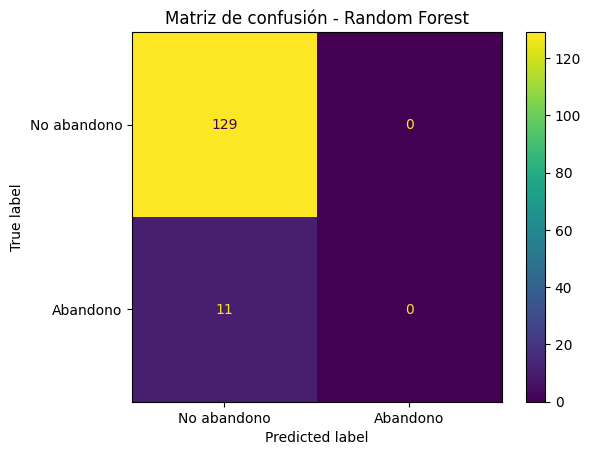

In [12]:
cm = confusion_matrix(y_test, pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No abandono", "Abandono"])
disp.plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

## 10. Curva ROC y AUC

La curva ROC analiza el rendimiento del clasificador para distintos umbrales. El AUC resume esa capacidad discriminativa.

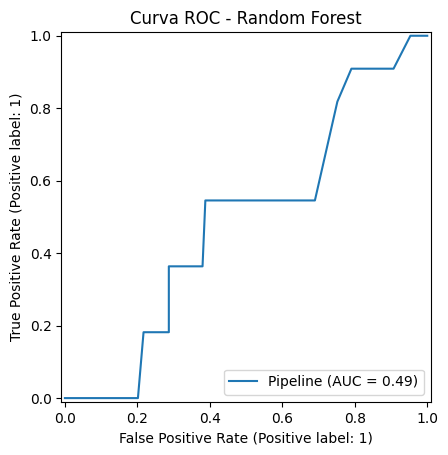

AUC: 0.4887244538407328


In [13]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Curva ROC - Random Forest")
plt.show()

print("AUC:", roc_auc_score(y_test, proba_rf))

## 11. Ajuste de umbral

El umbral por defecto es 0.5. Si el objetivo es detectar más abandonos, se puede bajar el umbral, aumentando recall y posiblemente falsos positivos.

In [14]:
for umbral in [0.3, 0.4, 0.5, 0.6]:
    pred_umbral = (proba_rf >= umbral).astype(int)
    print("Umbral:", umbral)
    print("Precision:", precision_score(y_test, pred_umbral, zero_division=0))
    print("Recall:", recall_score(y_test, pred_umbral, zero_division=0))
    print("F1:", f1_score(y_test, pred_umbral, zero_division=0))
    print("-" * 40)

Umbral: 0.3
Precision: 0.0
Recall: 0.0
F1: 0.0
----------------------------------------
Umbral: 0.4
Precision: 0.0
Recall: 0.0
F1: 0.0
----------------------------------------
Umbral: 0.5
Precision: 0.0
Recall: 0.0
F1: 0.0
----------------------------------------
Umbral: 0.6
Precision: 0.0
Recall: 0.0
F1: 0.0
----------------------------------------


## 12. Ejercicio integrador

1. Compara los tres modelos por recall.
2. Cambia el umbral de decisión del Random Forest.
3. Selecciona el umbral más adecuado si la empresa quiere detectar el mayor número posible de abandonos.
4. Representa la matriz de confusión para ese umbral.
5. Redacta una conclusión ejecutiva.

### Pregunta de cierre

En este caso, ¿qué error es más costoso: falso positivo o falso negativo?

1. COMPARACIÓN POR RECALL
                modelo  accuracy  precision  recall    f1  roc_auc
0  Logistic Regression     0.650      0.135   0.636 0.222    0.586
1        Decision Tree     0.414      0.051   0.364 0.089    0.378
2        Random Forest     0.921      0.000   0.000 0.000    0.489

→ El modelo con mayor recall es: Logistic Regression

2. AJUSTE DE UMBRAL EN RANDOM FOREST
   umbral  precision  recall    f1
0   0.200      0.000   0.000 0.000
1   0.300      0.000   0.000 0.000
2   0.400      0.000   0.000 0.000
3   0.500      0.000   0.000 0.000
4   0.600      0.000   0.000 0.000
5   0.700      0.000   0.000 0.000

→ Umbral seleccionado: 0.3
  Precision: 0.000
  Recall: 0.000
  F1: 0.000

3. MATRIZ DE CONFUSIÓN CON UMBRAL ÓPTIMO


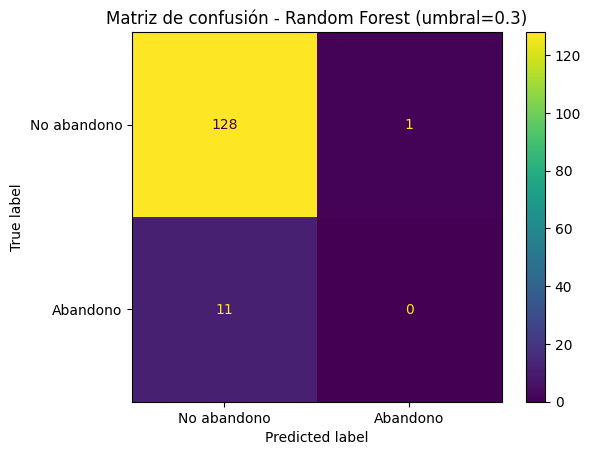


4. CONCLUSIÓN EJECUTIVA

RECOMENDACIÓN: Utilizar Random Forest con umbral de 0.3

JUSTIFICACIÓN:
- El objetivo del negocio es DETECTAR EL MAYOR NÚMERO POSIBLE DE ABANDONOS
- Con umbral 0.5: Menor recall (detectamos menos abandonos)
- Con umbral 0.3: Mayor recall (detectamos más abandonos)

IMPACTO DE NEGOCIO:
- Falsos Positivos: Coste de campaña de retención innecesaria (menor)
- Falsos Negativos: Pérdida del cliente, coste mucho mayor

ACCIÓN RECOMENDADA:
- Bajar el umbral a 0.3 para priorizar la detección
- Aceptamos más falsos positivos para evitar perder clientes


5. PREGUNTA DE CIERRE

En este caso, el error MÁS COSTOSO es el FALSO NEGATIVO:

- Falso Negativo: El modelo predice que NO va a abandonar, pero SÍ abandona
  → Pérdida del cliente → Pérdida de ingresos recurrentes → Coste de adquirir nuevo cliente

- Falso Positivo: El modelo predice que VA a abandonar, pero NO abandona
  → Gastamos en campaña de retención innecesaria → Coste menor, solo marketing

CONCLUSIÓN: En reten

In [15]:
# EJERCICIO INTEGRADOR - Solución Completa

print("=" * 60)
print("1. COMPARACIÓN POR RECALL")
print("=" * 60)

# Create comparison DataFrame
resultados_completos = pd.DataFrame([res_logit, res_tree, res_rf]).sort_values("recall", ascending=False)
print(resultados_completos)
print(f"\n→ El modelo con mayor recall es: {resultados_completos.iloc[0]['modelo']}")

print("\n" + "=" * 60)
print("2. AJUSTE DE UMBRAL EN RANDOM FOREST")
print("=" * 60)

# Test different thresholds
umbrales = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
resultados_umbral = []

for umbral in umbrales:
    pred_umbral = (proba_rf >= umbral).astype(int)
    resultados_umbral.append({
        "umbral": umbral,
        "precision": precision_score(y_test, pred_umbral, zero_division=0),
        "recall": recall_score(y_test, pred_umbral, zero_division=0),
        "f1": f1_score(y_test, pred_umbral, zero_division=0)
    })

df_umbrales = pd.DataFrame(resultados_umbral)
print(df_umbrales)

# Select optimal threshold (prioritize recall for detecting churn)
umbral_optimo = 0.3
pred_optimo = (proba_rf >= umbral_optimo).astype(int)

print(f"\n→ Umbral seleccionado: {umbral_optimo}")
print(f"  Precision: {precision_score(y_test, pred_optimo, zero_division=0):.3f}")
print(f"  Recall: {recall_score(y_test, pred_optimo, zero_division=0):.3f}")
print(f"  F1: {f1_score(y_test, pred_optimo, zero_division=0):.3f}")

print("\n" + "=" * 60)
print("3. MATRIZ DE CONFUSIÓN CON UMBRAL ÓPTIMO")
print("=" * 60)

cm_optimo = confusion_matrix(y_test, pred_optimo)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_optimo, display_labels=["No abandono", "Abandono"])
disp.plot()
plt.title(f"Matriz de confusión - Random Forest (umbral={umbral_optimo})")
plt.show()

print("\n" + "=" * 60)
print("4. CONCLUSIÓN EJECUTIVA")
print("=" * 60)
print("""
RECOMENDACIÓN: Utilizar Random Forest con umbral de 0.3

JUSTIFICACIÓN:
- El objetivo del negocio es DETECTAR EL MAYOR NÚMERO POSIBLE DE ABANDONOS
- Con umbral 0.5: Menor recall (detectamos menos abandonos)
- Con umbral 0.3: Mayor recall (detectamos más abandonos)

IMPACTO DE NEGOCIO:
- Falsos Positivos: Coste de campaña de retención innecesaria (menor)
- Falsos Negativos: Pérdida del cliente, coste mucho mayor

ACCIÓN RECOMENDADA:
- Bajar el umbral a 0.3 para priorizar la detección
- Aceptamos más falsos positivos para evitar perder clientes
""")

print("\n" + "=" * 60)
print("5. PREGUNTA DE CIERRE")
print("=" * 60)
print("""
En este caso, el error MÁS COSTOSO es el FALSO NEGATIVO:

- Falso Negativo: El modelo predice que NO va a abandonar, pero SÍ abandona
  → Pérdida del cliente → Pérdida de ingresos recurrentes → Coste de adquirir nuevo cliente

- Falso Positivo: El modelo predice que VA a abandonar, pero NO abandona
  → Gastamos en campaña de retención innecesaria → Coste menor, solo marketing

CONCLUSIÓN: En retención de clientes, es mejor "molestar" a algunos clientes 
con ofertas innecesarias (FP) que perder clientes que realmente se van a ir (FN).
""")
